### **Lab 2: Introduction to Complex Exponentials**

The goal of this laboratory is to gain familiarity with complex numbers and their use in representing sinusoidal signals as complex exponentials.

**Complex Numbers in Python**


Python can be used to compute complex-valued formulas and also to display the results as a vector or “phasor” diagrams.

Here are some of numpy package complex number functions (remember to import package):

*conj ()*       Complex conjugate

*abs ()*        Magnitude

*angle ()*      Angle (or phase) in radians

*real ()*       Real part

*imag ()*       Imaginary part
*j *        pre-defined as <math>&radic;-1</math>

*x = 3 + 4j*    j sufix defines imaginary constant

exp(1j<math>*</math>theta)  Function for the complex exponential

Each of these functions takes a vector (or matrix) as its input argument and operates on each element of the vector.

To display a complex number as a point in the complex plane you can directly use the provided function `plot_complex`. It can take a single number or a list of complex numbers as input. For instance, to display the complex number 2+1j:

In [ ]:
import numpy as np
from IPython.display import Audio

from util import load_audio, save_audio, plot_signals, plot_complex

In [2]:
z = 2 + 1j
plot_complex(z)

And for displaying several complex numbers:

In [3]:
z1 = 2 + 1j
z2 = 1j
z3 = -0.5j
plot_complex([z1, z2, z3], name=['z1', 'z2', 'z3'])

# **Exercises**

**1. Complex Numbers**

To exercise your understanding of complex numbers, do the following:

1.1. Define $z_1 = -1+j0.3$ and $z_2 = 0.8+j0.7$. Enter these in Python and plot them as points and vectors in the complex plane.

In [4]:
# Define 
z1 = -1 + 0.3j
z2 = 0.8 + 0.7j

# Plot them as vectors
plot_complex([z1, z2])

1.2. Compute the conjugate z* and the inverse 1/z for both $z_1$ and $z_2$ and plot the results as vectors in the complex plane.

In [14]:
# Compute conjugates and inverses
z1_conj = np.conj(z1)
z2_conj = np.conj(z2)

z1_inv = 1 / z1
z2_inv = 1 / z2

# Plot results with labels
plot_complex(
    [z1_conj, z2_conj, z1_inv, z2_inv],
    name=['z1*', 'z2*', '1/z1', '1/z2']
)

**2. Complex Exponentials**

Now let's work with complex exponentials. In python is very easy to work with these type of signals:

In [15]:
A = 0.5 # amplitude found in lab 1
f0 = 440.5
fs = 44100
phi = np.pi/2
t = np.arange(0, .1, 1.0/fs)
x = A * np.exp(1j*(2*f0*np.pi*t + phi))

Now we can plot the real and imaginary part of this signal:


In [16]:
plot_signals([np.real(x), np.imag(x)], fs, name=['real part', 'imag part'])

2.1. Define a complex exponential with the same parameters that those from Lab 1 (Ex 3.1) and plot the real part.

In [19]:
# Parameters from Lab 1 (Ex 3.1)
A = 0.5       # amplitude
f0 = 440.5    # frequency in Hz
fs = 44100    # sampling frequency
phi = np.pi/4 # phase in radians
duration = 1  # 1 second (for example)

# Time vector for 1 second
t = np.arange(0, duration, 1/fs)
T = 1 / f0
t_start = 0.2                 
t_end = t_start + 3 * T    

# Define the complex exponential
x = A * np.exp(1j * (2 * np.pi * f0 * t + phi))

# Plot only the real part
plot_signals([np.real(x)], fs, t_start=t_start, t_end=t_end, name=['real part of complex exponential'])


**3. Harmonic signals**

Now, we will work with harmonic signals. Until now, we have been working with simple sinusoids signals but most musical instruments sounds are harmonic. This means that they are formed by a sinusoid of the fundamental frequency plus sinusoids with frequencies multiples of it. For instance, we can define the following signal formed by the fundamental frequency plus the second and the third harmonic (note that each wave has a different phase).



In [ ]:
# clone repository
!git clone https://github.com/guillemmarti06/sis1_group103.git 
filepath = "./sis1_group103/audio_la.wav"
ref, fs = load_audio(filepath)

3.1. Load your reference audio signal and plot some periods (5-10) where the amplitude is stable. For instance see Ex. 2.3 from Lab 1.

In [33]:
# fundamental frequency 
f0 = 440 

# Define the time window 
t_start = 0.2                     # start time in seconds
t_end = t_start + 8 * (1 / f0)    # show about 8 periods

# Plot the reference signal in that window
plot_signals([ref], fs, t_start=t_start, t_end=t_end, name=['reference signal'])

3.2. Now, define a harmonic signal, `y` whose fundamental frequency is the defined in Lab 1. Go step by step adding a new harmonic in each step. Plot both signals (the reference and the synthesized) and try to reproduce the shape of the reference signal.

**Note 1**: in order to have a similar shape, we need to select the amplitudes and phases carefully. One way to do this is to define the harmonic signal as follows:

$$y(t) = \sum_{k=1}^K A_k\cos\left(2\pi kf_0 t + k \phi - (k-1)\pi/2 \right), $$

where $K$ is the number of harmonics, $f_0$ is the fundamental frequency, $A_k$ is the amplitude (weight) of each harmonic and $\phi$ is the phase of the signal (defined in Lab1 Ex 2.4).

**Note 2**:
Define the $A_k$ values relative to the fundamental frequency. This means to define $A_1=1$ and the others less than 1. You can use Audacity to plot the spectrum of the fragment selected of the reference audio and measure the relative amplitudes of the harmonics.

**Note 3**: Normalize the amplitude of the signal by the same amplitude of the reference. For instance, if the amplitude of the reference signal is 0.33, you can normalize the syntesized signal by first dividing by its maximum and then multiplyng by 0.33:

```
y = 0.33 * y / np.amax(y)
```

Harmonic 1: f = 440.0 Hz,  A = 0.7266,  φ = 2.822 rad
Harmonic 2: f = 880.0 Hz,  A = 0.3102,  φ = 0.171 rad
Harmonic 3: f = 1320.0 Hz,  A = 0.0246,  φ = -1.589 rad
Harmonic 4: f = 1760.0 Hz,  A = 0.0242,  φ = 1.784 rad
Harmonic 5: f = 2200.0 Hz,  A = 0.0160,  φ = -2.015 rad
Harmonic 6: f = 2640.0 Hz,  A = 0.0315,  φ = 2.362 rad
Harmonic 7: f = 3080.0 Hz,  A = 0.0152,  φ = -2.060 rad
Harmonic 8: f = 3520.0 Hz,  A = 0.0022,  φ = 1.133 rad
Harmonic 9: f = 3960.0 Hz,  A = 0.0013,  φ = -0.093 rad
Harmonic 10: f = 4400.0 Hz,  A = 0.0009,  φ = 0.445 rad


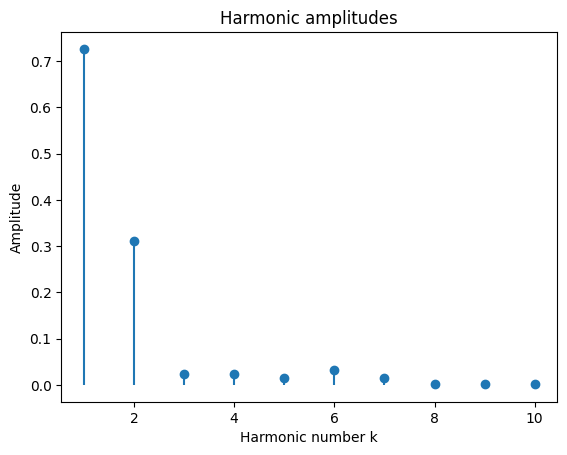

In [31]:
import matplotlib.pyplot as plt

f0 = 440    # Hz (fundamental from Lab 1)
t_start = 0.2      # same stable region as 3.1
t_end   = t_start + 8 * (1/f0)   # ~8 periods (adjust if you want)
N_harmonics = 10   # number of harmonics to extract/synthesize

# Extract the same segment
i_start = int(t_start * fs)
i_end   = int(t_end * fs)
segment = ref[i_start:i_end]

# FFT of the segment 
Y = np.fft.rfft(segment)
freqs = np.fft.rfftfreq(len(segment), 1/fs)

# Extract amplitudes and phases
amps, phases = [], []
for k in range(1, N_harmonics + 1):
    f_target = k * f0
    idx = np.argmin(np.abs(freqs - f_target))
    amps.append(2 * np.abs(Y[idx]) / len(Y))
    phases.append(np.angle(Y[idx]))

amps   = np.array(amps)
phases = np.array(phases)

# Print results
for k in range(N_harmonics):
    print(f"Harmonic {k+1}: f = {f0*(k+1):.1f} Hz,  A = {amps[k]:.4f},  φ = {phases[k]:.3f} rad")

# Visualize harmonic amplitudes 
plt.figure()
plt.stem(range(1, N_harmonics + 1), amps, basefmt=" ")
plt.xlabel("Harmonic number k")
plt.ylabel("Amplitude")
plt.title("Harmonic amplitudes")
plt.show()

In [34]:
t = np.arange(0, len(ref)/fs, 1.0/fs)
y = np.zeros_like(t)

for k in range(1, N_harmonics + 1):
    y += amps[k - 1] * np.cos(2 * np.pi * k * f0 * t + phases[k - 1])

# Normalize to match reference amplitude 
y = np.amax(ref) * y / np.amax(y)

# Compare reference vs synthesized 
t_start = 0.2
t_end = t_start + 8 * (1 / f0)
plot_signals([ref, y], fs, t_start=t_start, t_end=t_end, name=['Reference', 'Synthesis'])

3.3. Listen to the synthtesis and remark what are the main differences between the reference and synthesis.

In [35]:
print("Reference audio:")
display(Audio(ref, rate=fs))

print("Synthesized audio:")
display(Audio(y, rate=fs))

Reference audio:


Synthesized audio:


The synthesized signal somewhat reproduces the “La” tone, but its intensity remains constant over time. In contrast, the original piano note begins with a strong attack and gradually fades, creating a natural decay. Because of this, the synthesized version sounds artificial — it lacks the dynamic amplitude changes and rich harmonic content that give real instrument sounds their warmth and realism. Overall, it resembles the note’s basic pitch, but it’s far from capturing the natural character of an actual piano tone.